# Baseline Demand Forecasting with Prophet

This notebook documents the Prophet baseline model requested for Module 5 and follows the same project workflow used across the AI team.

## Business problem
GlobeNex needs a demand forecast that is explainable, easy to update, and suitable for business discussion with operations and procurement stakeholders.

## Workflow used
Business Problem -> Dataset Selection -> Target Variable Definition -> Feature Selection -> Train/Test Split -> Baseline Model Development -> Model Evaluation -> Business Interpretation -> MLflow Logging

## Dataset note
- Task brief name: `orders_cleaned.csv`
- Available project file used here: `data/cleaned/orders_clean.csv`


In [1]:
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "orders_clean.csv"
REPORT_DIR = PROJECT_ROOT / "Reports" / "module5_demand_forecasting"
MLFLOW_DIR = PROJECT_ROOT / "Models" / "mlruns"
MLFLOW_TRACKING_URI = MLFLOW_DIR.resolve().as_uri()
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON = 30
TEST_DAYS = 90


def build_daily_demand(path: Path) -> tuple[pd.DataFrame, pd.Series]:
    orders = pd.read_csv(path, parse_dates=["order_date"])
    daily = (
        orders.groupby("order_date", as_index=False)["order_quantity"]
        .sum()
        .sort_values("order_date")
    )
    series = daily.set_index("order_date")["order_quantity"].asfreq("D").fillna(0)
    return orders, series


def train_test_split_series(series: pd.Series, test_days: int = TEST_DAYS) -> tuple[pd.Series, pd.Series]:
    return series.iloc[:-test_days], series.iloc[-test_days:]


def mean_absolute_percentage_error(actual: pd.Series, predicted: pd.Series) -> float:
    actual = pd.Series(actual).replace(0, np.nan)
    predicted = pd.Series(predicted, index=actual.index)
    return (np.abs((actual - predicted) / actual)).dropna().mean() * 100


def evaluate_forecast(actual: pd.Series, predicted: pd.Series, model_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "model": model_name,
                "mae": mean_absolute_error(actual, predicted),
                "rmse": mean_squared_error(actual, predicted) ** 0.5,
                "mape": mean_absolute_percentage_error(actual, predicted),
            }
        ]
    )


orders, demand_series = build_daily_demand(DATA_PATH)
train_series, test_series = train_test_split_series(demand_series)

print(f"Data source: {DATA_PATH}")
print(f"Demand range: {demand_series.index.min().date()} to {demand_series.index.max().date()}")
print(f"Training window: {train_series.index.min().date()} to {train_series.index.max().date()}")
print(f"Testing window: {test_series.index.min().date()} to {test_series.index.max().date()}")

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pydantic\_internal\_fields.py:151: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source: D:\data science\Project intership\data\cleaned\orders_clean.csv
Demand range: 2021-01-01 to 2024-12-31
Training window: 2021-01-01 to 2024-10-02
Testing window: 2024-10-03 to 2024-12-31


## 1. Dataset selection and target definition

The modeling target is daily aggregated demand from `order_quantity`. Prophet expects a two-column structure:
- `ds`: timestamp
- `y`: target value


In [2]:
prophet_df = demand_series.reset_index().rename(columns={"order_date": "ds", "order_quantity": "y"})
prophet_df.head()

,ds,y
0,2021-01-01,3037
1,2021-01-02,3605
2,2021-01-03,3252
3,2021-01-04,3362
4,2021-01-05,2864


## 2. Data preparation and seasonality review

Prophet handles trend and seasonal components directly, but we still review the data first so the model narrative stays tied to the business context.


In [3]:
profile = pd.DataFrame(
    [
        {
            "daily_rows": len(demand_series),
            "date_start": demand_series.index.min().date(),
            "date_end": demand_series.index.max().date(),
            "peak_demand": int(demand_series.max()),
            "peak_date": demand_series.idxmax().date(),
        }
    ]
)
profile

,daily_rows,date_start,date_end,peak_demand,peak_date
0,1461,2021-01-01,2024-12-31,210469,2024-12-31


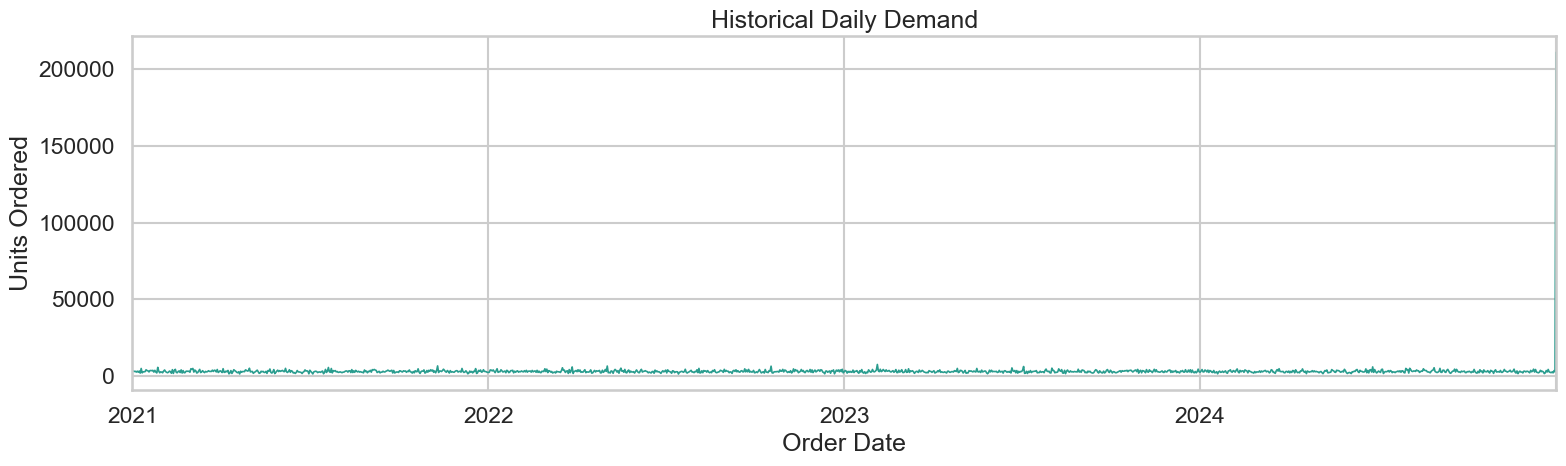

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
demand_series.plot(ax=ax, color="#2a9d8f", linewidth=1.2)
ax.set_title("Historical Daily Demand")
ax.set_xlabel("Order Date")
ax.set_ylabel("Units Ordered")
fig.tight_layout()

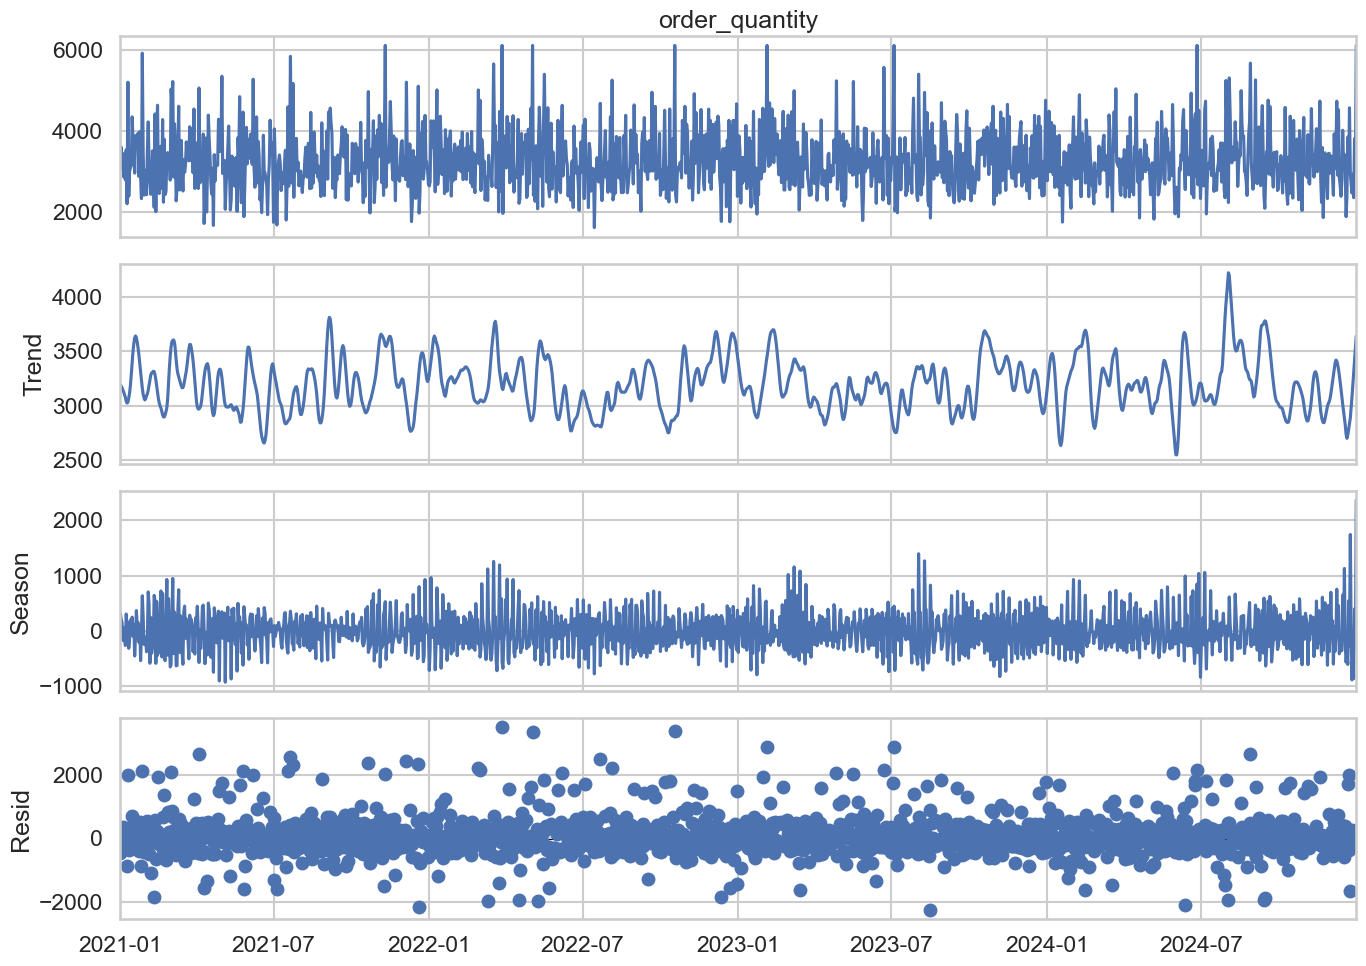

In [5]:
capped_series = demand_series.clip(upper=demand_series.quantile(0.995))
stl_result = STL(capped_series, period=7, robust=True).fit()
fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.tight_layout()

## 3. Train/test split

The final **90 days** are held out for evaluation so the baseline can be assessed on unseen observations from **2024-10-03 through 2024-12-31**.


In [6]:
train_df = prophet_df.iloc[:-TEST_DAYS].copy()
test_df = prophet_df.iloc[-TEST_DAYS:].copy()

pd.DataFrame(
    [
        {
            "train_start": train_df["ds"].min().date(),
            "train_end": train_df["ds"].max().date(),
            "test_start": test_df["ds"].min().date(),
            "test_end": test_df["ds"].max().date(),
            "test_days": len(test_df),
        }
    ]
)

,train_start,train_end,test_start,test_end,test_days
0,2021-01-01,2024-10-02,2024-10-03,2024-12-31,90


## 4. Baseline model development

The Prophet baseline is configured with:
- yearly seasonality enabled
- weekly seasonality enabled
- daily seasonality disabled
- additive seasonality mode
- `changepoint_prior_scale = 0.05`

This is intentionally conservative so it can serve as a benchmark rather than an overfit model.


In [7]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
)
prophet_model.fit(train_df)

21:23:23 - cmdstanpy - INFO - Chain [1] start processing
21:23:23 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = prophet_model.make_future_dataframe(periods=len(test_df), freq="D", include_history=True)
forecast = prophet_model.predict(future)
prophet_test = forecast.set_index("ds").loc[test_df["ds"], ["yhat", "yhat_lower", "yhat_upper"]]
prophet_pred = pd.Series(prophet_test["yhat"].values, index=test_df["ds"], name="prophet_prediction")
prophet_eval = evaluate_forecast(test_df.set_index("ds")["y"], prophet_pred, "Prophet")
prophet_eval

,model,mae,rmse,mape
0,Prophet,"2,858.998","21,840.646",20.336


## 5. Forecast, confidence intervals, and components

Prophet exposes a business-friendly view of the forecast by separating the overall trend from recurring seasonal effects.


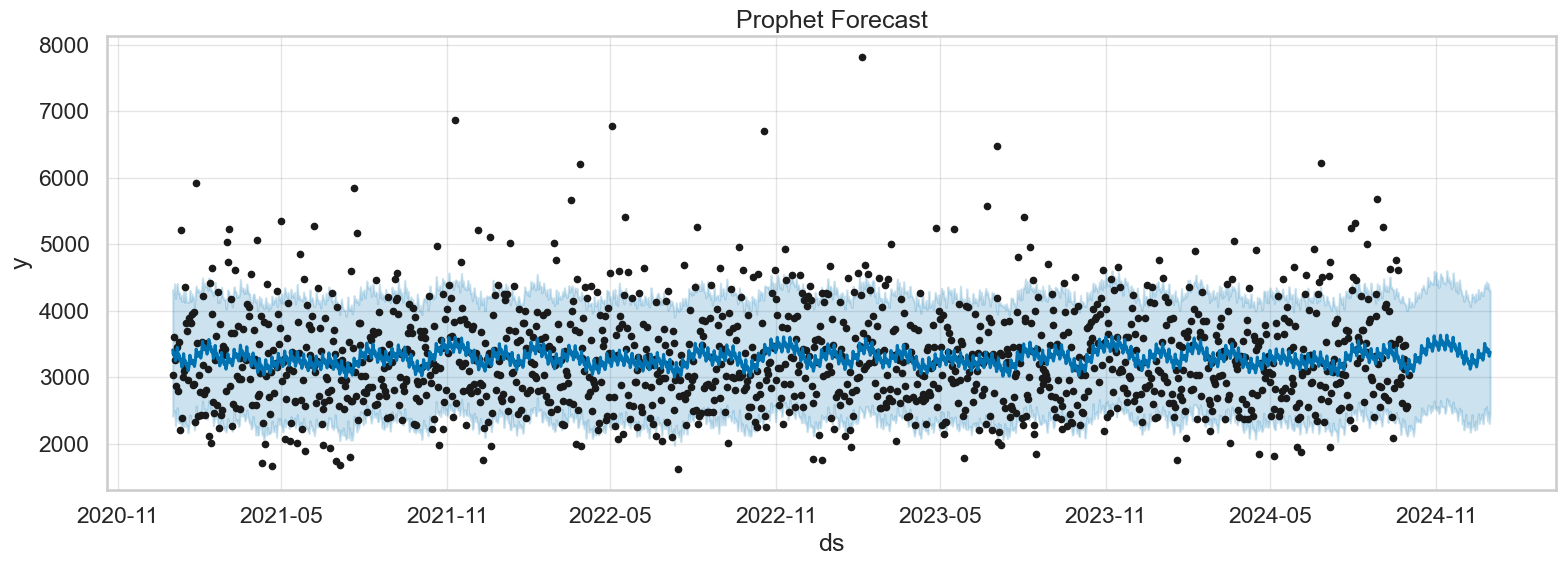

In [9]:
fig = prophet_model.plot(forecast)
fig.set_size_inches(16, 6)
fig.axes[0].set_title("Prophet Forecast")
fig.tight_layout()

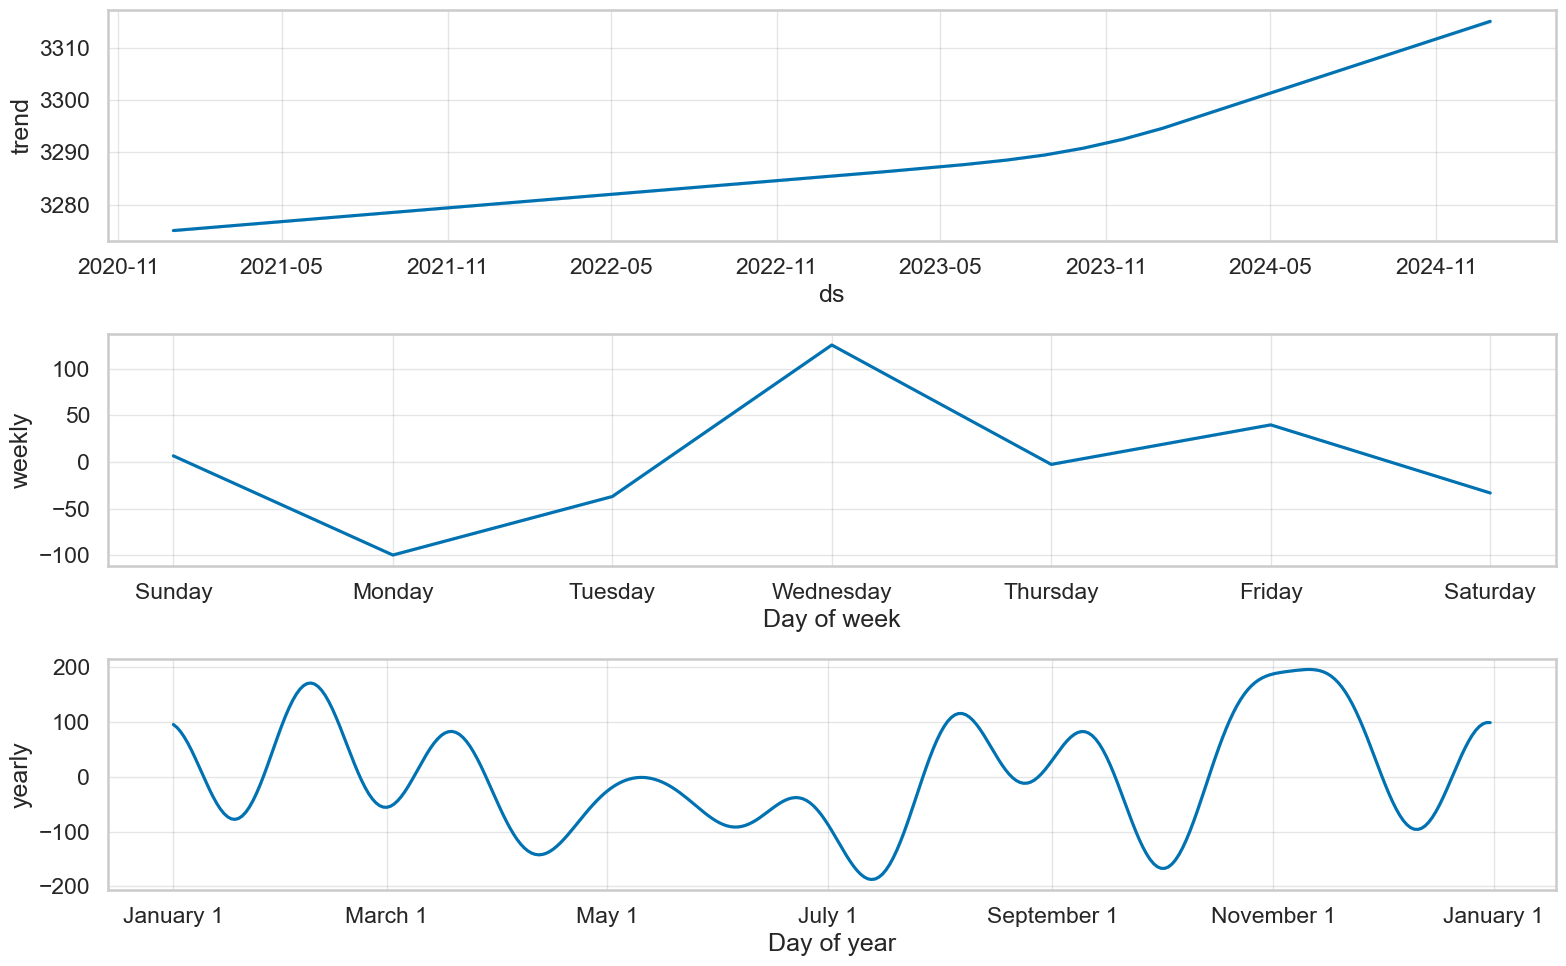

In [10]:
fig = prophet_model.plot_components(forecast)
fig.set_size_inches(16, 10)
fig.tight_layout()

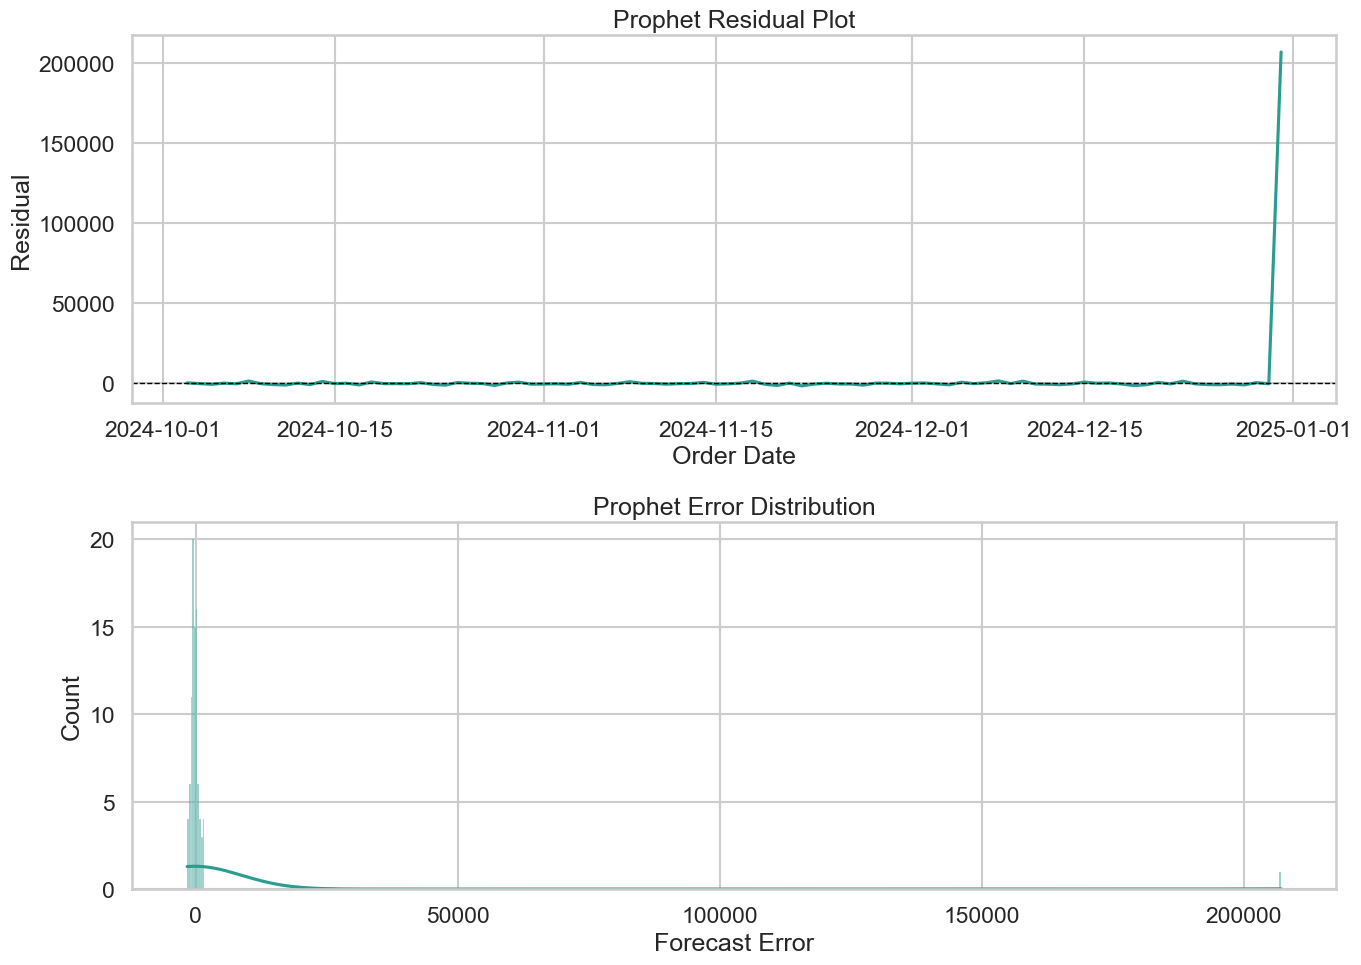

In [11]:
prophet_residuals = test_df.set_index("ds")["y"] - prophet_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(test_df["ds"], prophet_residuals, color="#2a9d8f")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Prophet Residual Plot")
axes[0].set_xlabel("Order Date")
axes[0].set_ylabel("Residual")

sns.histplot(prophet_residuals, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Prophet Error Distribution")
axes[1].set_xlabel("Forecast Error")
fig.tight_layout()

## 6. Future demand forecast

For the operational 30-day look-ahead, the model is refit on a capped full-history series so the extreme 2024-12-31 spike does not overwhelm January planning outputs.


In [12]:
future_ready_df = capped_series.reset_index().rename(columns={"order_date": "ds", "order_quantity": "y"})
future_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
)
future_model.fit(future_ready_df)
future_dates = future_model.make_future_dataframe(periods=FORECAST_HORIZON, freq="D", include_history=True)
future_forecast = future_model.predict(future_dates).tail(FORECAST_HORIZON)
future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend"]].head(10)

21:23:26 - cmdstanpy - INFO - Chain [1] start processing
21:23:26 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,trend
1461,2025-01-01,"3,465.101","2,534.884","4,328.337","3,266.332"
1462,2025-01-02,"3,346.435","2,486.728","4,209.948","3,266.317"
1463,2025-01-03,"3,387.519","2,439.944","4,353.946","3,266.303"
1464,2025-01-04,"3,305.211","2,396.049","4,257.725","3,266.289"
1465,2025-01-05,"3,360.716","2,381.049","4,259.128","3,266.274"
1466,2025-01-06,"3,246.363","2,401.328","4,215.263","3,266.260"
1467,2025-01-07,"3,300.674","2,407.082","4,182.087","3,266.246"
1468,2025-01-08,"3,406.782","2,432.766","4,375.583","3,266.231"
1469,2025-01-09,"3,278.133","2,342.449","4,130.943","3,266.217"
1470,2025-01-10,"3,311.107","2,320.750","4,225.134","3,266.203"


## 7. MLflow logging

The baseline run is logged locally so future improvements can be compared against the exact same benchmark.


In [13]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("module5_demand_forecasting")

with mlflow.start_run(run_name="prophet_baseline_notebook"):
    mlflow.log_param("data_path", str(DATA_PATH.relative_to(PROJECT_ROOT)))
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("daily_seasonality", False)
    mlflow.log_param("changepoint_prior_scale", 0.05)
    for metric_name, metric_value in prophet_eval.iloc[0].items():
        if metric_name != "model":
            mlflow.log_metric(metric_name, float(metric_value))

## 8. Business interpretation

- Prophet is useful when business stakeholders want a direct view of trend and seasonal components.
- The model captures a stable weekly pattern, but its error profile remains sensitive to the end-of-year spike on **2024-12-31**.
- Prophet should remain part of the baseline comparison, especially for explainability, but the final promotion decision should be based on the shared evaluation report.

See `Reports/module5_demand_forecasting/forecast_comparison_report.md` for the side-by-side recommendation.
